
=== Testing 2 qubits (matrix size 4x4) ===
  Trial  1: Orig=  10  Cut=   8  LW=   7  Pauli=10
  Trial  2: Orig=  10  Cut=   8  LW=   7  Pauli=10
  Trial  3: Orig=  10  Cut=   7  LW=   8  Pauli=10
  Trial  4: Orig=   9  Cut=   8  LW=   8  Pauli=10
  Trial  5: Orig=   9  Cut=   8  LW=   8  Pauli=10
  Trial  6: Orig=   9  Cut=   8  LW=   9  Pauli=10
  Trial  7: Orig=  10  Cut=   8  LW=   7  Pauli=10
  Trial  8: Orig=  10  Cut=   8  LW=   8  Pauli=10
  Trial  9: Orig=  10  Cut=   8  LW=   8  Pauli=11
  Trial 10: Orig=  10  Cut=   8  LW=   6  Pauli=11
  Trial 11: Orig=  10  Cut=   8  LW=   8  Pauli=10
  Trial 12: Orig=  10  Cut=  10  LW=   7  Pauli=10
  Trial 13: Orig=  10  Cut=   8  LW=   9  Pauli=10
  Trial 14: Orig=  10  Cut=  10  LW=   8  Pauli=10
  Trial 15: Orig=  10  Cut=   6  LW=   6  Pauli=10
  Trial 16: Orig=  10  Cut=   8  LW=   8  Pauli=10
  Trial 17: Orig=  10  Cut=   8  LW=   7  Pauli=10
  Trial 18: Orig=  10  Cut=   8  LW=   7  Pauli=10
  Trial 19: Orig=  10  Cut=  10  LW=  

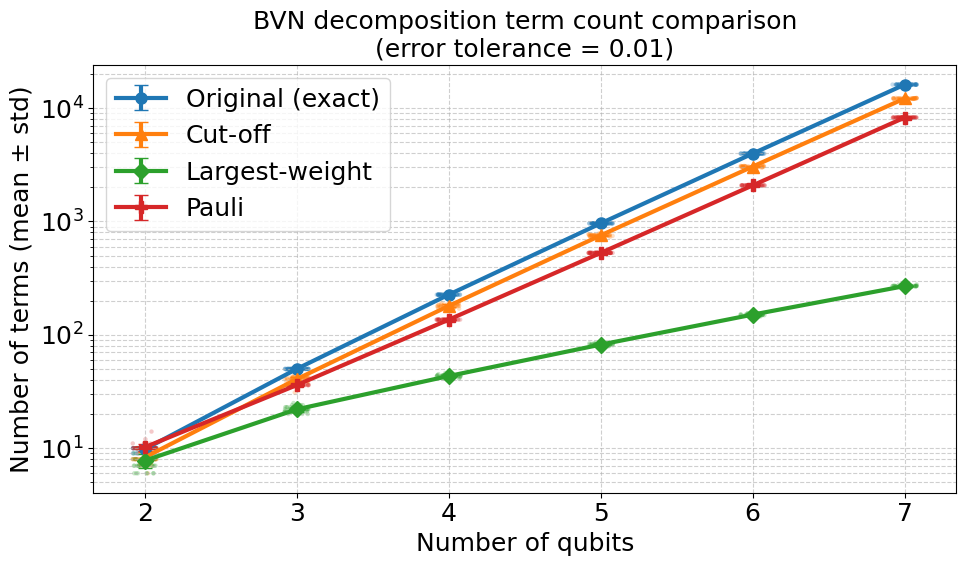

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import time
from typing import List, Tuple, Optional
import warnings
warnings.filterwarnings("ignore")

# ----------------------------------------------------------------------
# PennyLane import (fall back gracefully if not installed)
# ----------------------------------------------------------------------
try:
    import pennylane as qml
    HAVE_PENNYLANE = True
except ImportError:
    HAVE_PENNYLANE = False
    print("PennyLane not found – Pauli decomposition will be skipped.")

# ----------------------------------------------------------------------
# 1. BVN helpers (your code, slightly rearranged)
# ----------------------------------------------------------------------
def construct_bipartite_graph(A):
    n = len(A)
    B = nx.Graph()
    row_nodes = np.arange(n)
    col_nodes = np.arange(n) + n
    B.add_nodes_from(row_nodes, bipartite=0)
    B.add_nodes_from(col_nodes, bipartite=1)
    for i in range(n):
        for j in range(n):
            if A[i, j] != 0:
                B.add_edge(i, j + n)
    return B

def get_maximal_matching(A):
    n = len(A)
    G = construct_bipartite_graph(A)
    top_nodes = [node for node in G.nodes if G.nodes[node]["bipartite"] == 0]
    matching = nx.bipartite.maximum_matching(G, top_nodes=top_nodes)
    return matching

def permutation_from_bipartite_matching(matching):
    n = len(matching) // 2
    if len(matching) != 2 * n:
        return None, None
    prow = np.zeros(n, dtype=int)
    for i in range(n):
        prow[i] = matching[i] % n
    P = np.zeros((n, n), dtype=int)
    P[np.arange(n), prow] = 1
    return P, prow

def find_permutation(S):
    matching = get_maximal_matching(S)
    return permutation_from_bipartite_matching(matching)

def compute_weight(Si, Pi):
    nonzeros = np.nonzero(Pi)
    return np.min(Si[nonzeros])

def reconstruct_matrix(Prows, weights, n):
    S = np.zeros((n, n), dtype=float)
    for w, p in zip(weights, Prows):
        P = np.zeros((n, n), dtype=float)
        P[np.arange(n), p] = 1.0
        S += w * P
    return S

# ----------------------------------------------------------------------
# 2. Original greedy BVN (exact)
# ----------------------------------------------------------------------
def bvn_original(S, precision=1e-6, max_iter=5000):
    Prows = []
    weights = []
    Si = S.copy().astype(float)
    eps = np.linalg.norm(Si, 1)
    i = 0
    while eps > precision and i < max_iter:
        Pi, prow = find_permutation(Si)
        if Pi is None:
            break
        weight = compute_weight(Si, Pi)
        Si -= weight * Pi
        weights.append(weight)
        Prows.append(prow)
        eps = np.linalg.norm(Si, 1)
        i += 1
    total = sum(weights)
    if total > 0:
        weights = [w / total for w in weights]
    return Prows, weights

# ----------------------------------------------------------------------
# 3. Threshold BVN (your implementation)
# ----------------------------------------------------------------------
def bvn_threshold(S, precision=0.001, max_iter=100, threshold=0.0, normalize_weights=False):
    Prows = []
    weights = []
    Si = S.copy().astype(float)
    n = S.shape[0]
    epsilon = np.linalg.norm(Si, 1)
    i = 0
    while epsilon > precision and i < max_iter:
        B = nx.Graph()
        row_nodes = np.arange(n)
        col_nodes = np.arange(n) + n
        B.add_nodes_from(row_nodes, bipartite=0)
        B.add_nodes_from(col_nodes, bipartite=1)
        for u in range(n):
            for v in range(n):
                if Si[u, v] > threshold:
                    B.add_edge(u, v + n)
        top_nodes = [node for node in B.nodes if B.nodes[node]["bipartite"] == 0]
        matching = nx.bipartite.maximum_matching(B, top_nodes=top_nodes)
        if len(matching) != 2 * n:
            break
        prow = np.zeros(n, dtype=int)
        for u in range(n):
            prow[u] = matching[u] % n
        P = np.zeros((n, n), dtype=int)
        P[np.arange(n), prow] = 1
        weight = np.min(Si[P == 1])
        Si -= weight * P
        weights.append(weight)
        Prows.append(prow)
        epsilon = np.linalg.norm(Si, 1)
        i += 1
    if normalize_weights:
        total = sum(weights)
        if total > 0:
            weights = [w / total for w in weights]
    return Prows, weights

# ----------------------------------------------------------------------
# 4. Cut-off BVN (post-process full decomposition)
# ----------------------------------------------------------------------
def bvn_cutoff(S, precision=0.01, max_iter=5000, norm="fro"):
    n = S.shape[0]
    Prows_full, weights_full = bvn_original(S, precision=1e-6, max_iter=max_iter)
    if not Prows_full:
        return [], []
    terms = [(weights_full[i], Prows_full[i], i) for i in range(len(weights_full))]
    terms.sort(key=lambda x: x[0])
    keep_idx = set(range(len(weights_full)))
    def reconstruction_error(kept_indices):
        ws = [weights_full[i] for i in kept_indices]
        total = sum(ws)
        if total == 0:
            return float("inf")
        ws_renorm = [w / total for w in ws]
        A = np.zeros((n, n))
        for w, i in zip(ws_renorm, kept_indices):
            A[np.arange(n), Prows_full[i]] += w
        if norm == "fro":
            return np.linalg.norm(S - A, "fro")
        else:
            return np.linalg.norm(S - A, 1)
    best_err = reconstruction_error(keep_idx)
    for w, prow, idx in terms:
        if len(keep_idx) == 1:
            break
        candidate = keep_idx - {idx}
        err = reconstruction_error(candidate)
        if err <= precision:
            keep_idx = candidate
            best_err = err
        else:
            break
    final_ws = [weights_full[i] for i in keep_idx]
    total_w = sum(final_ws)
    final_ws_renorm = [w / total_w for w in final_ws] if total_w > 0 else []
    final_prows = [Prows_full[i] for i in keep_idx]
    return final_prows, final_ws_renorm

# ----------------------------------------------------------------------
# 5. Largest‑weight early‑stopping BVN (your “bvn” function)
# ----------------------------------------------------------------------
def bvn_largest_weights(S, precision=0.01, max_iter=5000, norm="fro"):
    n = S.shape[0]
    Prows = []
    weights = []
    residual = S.copy()
    def current_error():
        total = sum(weights)
        if total == 0:
            return float("inf")
        renorm_weights = np.array(weights) / total
        approx = np.zeros((n, n))
        for w, p in zip(renorm_weights, Prows):
            approx[np.arange(n), p] += w
        if norm == "fro":
            return np.linalg.norm(S - approx, "fro")
        else:
            return np.linalg.norm(S - approx, 1)
    for _ in range(max_iter):
        G = nx.Graph()
        row_nodes = np.arange(n)
        col_nodes = np.arange(n) + n
        G.add_nodes_from(row_nodes, bipartite=0)
        G.add_nodes_from(col_nodes, bipartite=1)
        for i in range(n):
            for j in range(n):
                if residual[i, j] > 0:
                    G.add_edge(i, j + n, weight=residual[i, j])
        matching_set = nx.algorithms.matching.max_weight_matching(
            G, maxcardinality=True, weight="weight"
        )
        if len(matching_set) != n:
            break
        prow = np.zeros(n, dtype=int)
        for u, v in matching_set:
            if u < n:
                prow[u] = v - n
            else:
                prow[v] = u - n
        weight = np.min(residual[np.arange(n), prow])
        if weight <= 0:
            break
        Prows.append(prow)
        weights.append(weight)
        residual[np.arange(n), prow] -= weight
        if current_error() <= precision:
            break
    total = sum(weights)
    if total > 0:
        weights = [w / total for w in weights]
    return Prows, weights

# ----------------------------------------------------------------------
# 6. Sinkhorn scaling
# ----------------------------------------------------------------------
def sinkhorn(A, max_iter=1000, tol=1e-6):
    A = np.array(A, dtype=float)
    A = A / A.sum()
    for _ in range(max_iter):
        row_sum = A.sum(axis=1, keepdims=True)
        A = A / row_sum
        col_sum = A.sum(axis=0, keepdims=True)
        A = A / col_sum
        if np.max(np.abs(row_sum - 1)) < tol and np.max(np.abs(col_sum - 1)) < tol:
            break
    return A

# ----------------------------------------------------------------------
# 7. Random symmetric doubly stochastic matrix generator
# ----------------------------------------------------------------------
def random_symmetric_doubly_stochastic(n):
    """Create a random n×n doubly stochastic symmetric matrix."""
    A = np.random.uniform(0.1, 1.0, (n, n))
    A = (A + A.T) / 2   # symmetrize
    return sinkhorn(A)

# ----------------------------------------------------------------------
# 8. PennyLane Pauli decomposition wrapper
# ----------------------------------------------------------------------
def pauli_decompose_term_count(matrix, wire_order):
    """Return number of Pauli terms of the real symmetric matrix."""
    if not HAVE_PENNYLANE:
        return None
    # PennyLane’s pauli_decompose expects a matrix and wire order
    try:
        ps = qml.pauli_decompose(matrix, pauli=True, wire_order=wire_order)
        return len(ps)
    except Exception as e:
        print(f"Pauli decompose failed: {e}")
        return None

# ----------------------------------------------------------------------
# 9. Automated threshold search for BVN‑threshold
# ----------------------------------------------------------------------
def find_best_threshold_bvn(S, prec, max_iter=5000):
    """Binary search for threshold that gives error ≤ prec with minimal terms."""
    n = len(S)
    low, high = 0.0, 1.0
    best_terms = n * 2  # large initial
    best_thr = None
    best_err = float("inf")
    Prows_best, w_best = [], []
    for _ in range(25):
        mid = (low + high) / 2
        Prows, w = bvn_threshold(S, precision=1e-6, max_iter=max_iter, threshold=mid,
                                 normalize_weights=True)
        if not Prows:
            high = mid
            continue
        S_th = reconstruct_matrix(Prows, w, n)
        err = np.linalg.norm(S - S_th, "fro")
        if err <= prec:
            low = mid
            if len(Prows) < best_terms or (len(Prows) == best_terms and err < best_err):
                best_thr = mid
                best_terms = len(Prows)
                best_err = err
                Prows_best, w_best = Prows, w
        else:
            high = mid
    if best_thr is None:  # fallback to full decomposition if no threshold works
        Prows_best, w_best = bvn_original(S, precision=1e-6, max_iter=max_iter)
    return Prows_best, w_best

# ----------------------------------------------------------------------
# 10. Main comparison loop
# ----------------------------------------------------------------------
def run_comparison(qubits_list= [2, 3, 4, 5, 6, 7, 8],num_trials = 5, precision = 0.01):
    # qubit numbers to test (matrix size = 2**n_qubits)
 
    
     # error tolerance for BVN approximations

    # storage: method -> qubit -> list of term counts
    methods = {
        "Original (exact)": [],
        "Cut-off": [],
        "Largest-weight": [],
    }
    if HAVE_PENNYLANE:
        methods["Pauli"] = []

    # preallocate lists per method
    for method in methods:
        methods[method] = {q: [] for q in qubits_list}

    for n_q in qubits_list:
        n = 2 ** n_q
        print(f"\n=== Testing {n_q} qubits (matrix size {n}x{n}) ===")
        for trial in range(1, num_trials + 1):
            S = random_symmetric_doubly_stochastic(n)
            # original
            Prows_o, w_o = bvn_original(S, max_iter=5**(n_q))
            methods["Original (exact)"][n_q].append(len(Prows_o))

            # cut-off
            Prows_c, w_c = bvn_cutoff(S, precision=precision, max_iter=5**(n_q))
            methods["Cut-off"][n_q].append(len(Prows_c))
            # largest-weight
            Prows_l, w_l = bvn_largest_weights(S, precision=precision)
            methods["Largest-weight"][n_q].append(len(Prows_l))
            # Pauli
            if HAVE_PENNYLANE:
                pcnt = pauli_decompose_term_count(S, wire_order=range(n_q))
                if pcnt is not None:
                    methods["Pauli"][n_q].append(pcnt)
                else:
                    methods["Pauli"][n_q].append(np.nan)
            print(f"  Trial {trial:2d}: Orig={len(Prows_o):4d}"
                  f"  Cut={len(Prows_c):4d}  LW={len(Prows_l):4d}"
                  f"  Pauli={methods['Pauli'][n_q][-1] if 'Pauli' in methods else '--'}")
        # print averages
        for method in methods:
            vals = methods[method][n_q]
            print(f"    {method:20s}: mean={np.mean(vals):6.1f}  std={np.std(vals):6.1f}")

    # # ------------------------------------------------------------------
    # # 11. Plot, in version 1
    # # ------------------------------------------------------------------
    # plt.figure(figsize=(10, 6))
    # markers = {'Original (exact)': 'o-', 'Threshold': 's--', 'Cut-off': '^-.',
    #            'Largest-weight': 'D:', 'Pauli': 'P-'}
    # for method, data in methods.items():
    #     xs = qubits_list
    #     ys = [np.mean(data[q]) for q in qubits_list]
    #     yerr = [np.std(data[q]) for q in qubits_list]
    #     plt.errorbar(xs, ys, yerr=yerr, label=method, marker=markers.get(method[0], 'o'),
    #                  markersize=8, capsize=5)
    # plt.yscale("log")
    # plt.xlabel("Number of qubits")
    # plt.ylabel("Number of terms (mean ± std)")
    # plt.title(f"BVN decomposition term count comparison\n(error tolerance = {precision})")
    # plt.legend()
    # plt.grid(True, which="both", ls="--", alpha=0.6)
    # plt.tight_layout()
    # plt.savefig("bvn_term_comparison.pdf")
    # plt.savefig("bvn_term_comparison.png", dpi=150)
    # plt.show()
    # ------------------------------------------------------------------
    # 11. Plot (mean ± std, with individual trials)
    # ------------------------------------------------------------------
    plt.figure(figsize=(10, 6))

    # define method colors manually or use the existing markers
    colors = {
        'Original (exact)': 'C0',
        'Cut-off': 'C1',
        'Largest-weight': 'C2',
        'Pauli': 'C3',
    }
    markers = {
        'Original (exact)': 'o',
        'Cut-off': '^',
        'Largest-weight': 'D',
        'Pauli': 'P',
    }

    for method, data in methods.items():
        xs = qubits_list
        ys = [np.mean(data[q]) for q in qubits_list]
        yerr = [np.std(data[q]) for q in qubits_list]
        color = colors[method]
        marker = markers[method]

        # plot individual trials (jittered, semi-transparent)
        for q in qubits_list:
            x_jitter = q + np.random.uniform(-0.08, 0.08, size=len(data[q]))
            plt.scatter(x_jitter, data[q],
                        alpha=0.25, s=10, color=color,
                        edgecolors='none', zorder=1)

        # mean ± std line
        plt.errorbar(xs, ys, yerr=yerr, label=method,
                    color=color, marker=marker,
                    markersize=8, capsize=5, linewidth=3, zorder=2)

    plt.yscale("log")
    plt.xlabel("Number of qubits")
    plt.ylabel("Number of terms (mean ± std)")
    plt.title(f"BVN decomposition term count comparison\n(error tolerance = {precision})")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig("bvn_term_comparison.pdf")
    plt.savefig("bvn_term_comparison.png", dpi=150)
    plt.show()

def plot_precision_vs_terms(n_qubits=6, n_trials=3,
                            epsilon_range=(0.0001, 0.1, 4),
                            save_prefix="precision_vs_terms"):
    """
    For a fixed number of qubits, measure the number of terms obtained by
    largest‑weight BVN at different precision levels, and compare with the
    theoretical bottleneck bound N * ln(1/epsilon).

    Parameters
    ----------
    n_qubits : int
        Number of qubits (matrix size N = 2**n_qubits).
    n_trials : int
        Number of random doubly stochastic matrices to average over.
    epsilon_range : tuple (start, stop, num_points)
        Precision values to test (logarithmic spacing recommended).
    save_prefix : str
        Prefix for output PDF/PNG files.
    """
    N = 2 ** n_qubits
    epsilons = np.logspace(np.log10(epsilon_range[0]),
                           np.log10(epsilon_range[1]),
                           epsilon_range[2])

    mean_terms = np.zeros_like(epsilons)
    std_terms = np.zeros_like(epsilons)

    for i, eps in enumerate(epsilons):
        term_counts = []
        for _ in range(n_trials):
            S = random_symmetric_doubly_stochastic(N)   # from your earlier code
            _, weights = bvn_largest_weights(S, precision=eps, max_iter=5000)
            term_counts.append(len(weights))
        mean_terms[i] = np.mean(term_counts)
        std_terms[i] = np.std(term_counts)

    # Theoretical bottleneck bound
    theoretical = N * np.log(1.0 / epsilons)

    # ---- Plotting ----
    fig, ax = plt.subplots(figsize=(10, 6))

    # Experimental data
    ax.errorbar(epsilons, mean_terms, yerr=std_terms,
                marker='o', capsize=4, color='C0', label='Largest‑weight BVN')

    # Theoretical bound
    ax.plot(epsilons, theoretical, '--', color='C1',
            label=f'Bottleneck bound: $N \\ln(1/\\varepsilon)$\n'
                  f'($N={N}$)')

    ax.set_xscale('log')
    ax.set_xlabel('Precision $\\varepsilon$')
    ax.set_ylabel('Number of permutations $K$')
    ax.set_title(f'Term count vs. precision ({n_qubits} qubits, $N={N}$)')
    ax.legend()
    ax.grid(True, which='both', ls='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig(f"{save_prefix}_{n_qubits}qubits.pdf", dpi=150)
    plt.savefig(f"{save_prefix}_{n_qubits}qubits.png", dpi=150)
    plt.show()

# Example usage:
# plot_precision_vs_terms(n_qubits=6, n_trials=3)
import numpy as np
import matplotlib.pyplot as plt
if __name__ == "__main__":
    plt.rcParams.update(
        {
            "font.size": 18,
            "axes.titlesize": 18,
            "axes.labelsize": 18,
            "xtick.labelsize": 18,
            "ytick.labelsize": 18,
            "legend.fontsize": 18,
            "figure.titlesize": 18,
            "figure.figsize": (10, 5),
            "figure.dpi": 100,
            "savefig.dpi": 300,
            "lines.linewidth": 3,
            "lines.markersize": 8,
        }
    )
    np.random.seed(42)
    run_comparison(qubits_list= [2, 3,4,5,6,7], num_trials = 50, precision = 0.01)
    # for n in range(3,4,2):
    #     plot_precision_vs_terms(n_qubits=n, n_trials=50)